# Self-Organizing Maps

## Importing the libraries

In [2]:
pip install minisom


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [4]:
df = pd.read_csv('Credit_Card_Applications.csv')

df


,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,15776156,1,22.08,11.460,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,15739548,0,22.67,7.000,2,8,4,0.165,0,0,0,0,2,160,1,0
2,15662854,0,29.58,1.750,1,4,4,1.250,0,0,0,1,2,280,1,0
3,15687688,0,21.67,11.500,1,5,3,0.000,1,1,11,1,2,0,1,1
4,15715750,1,20.17,8.170,2,6,4,1.960,1,1,14,0,2,60,159,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,15808223,1,31.57,10.500,2,14,4,6.500,1,0,0,0,2,0,1,1
686,15769980,1,20.67,0.415,2,8,4,0.125,0,0,0,0,2,0,45,0
687,15675450,0,18.83,9.540,2,6,4,0.085,1,0,0,0,2,100,1,1
688,15776494,0,27.42,14.500,2,14,8,3.085,1,1,1,0,2,120,12,1


In [5]:
inputs = df.drop(['Class','CustomerID'], axis=1)
target = df['Class']

In [6]:
inputs

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14
0,1,22.08,11.460,2,4,4,1.585,0,0,0,1,2,100,1213
1,0,22.67,7.000,2,8,4,0.165,0,0,0,0,2,160,1
2,0,29.58,1.750,1,4,4,1.250,0,0,0,1,2,280,1
3,0,21.67,11.500,1,5,3,0.000,1,1,11,1,2,0,1
4,1,20.17,8.170,2,6,4,1.960,1,1,14,0,2,60,159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,1,31.57,10.500,2,14,4,6.500,1,0,0,0,2,0,1
686,1,20.67,0.415,2,8,4,0.125,0,0,0,0,2,0,45
687,0,18.83,9.540,2,6,4,0.085,1,0,0,0,2,100,1
688,0,27.42,14.500,2,14,8,3.085,1,1,1,0,2,120,12


In [7]:
target

0      0
1      0
2      0
3      1
4      1
      ..
685    1
686    0
687    1
688    1
689    1
Name: Class, Length: 690, dtype: int64

## Feature Scaling

In [8]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range = (0, 1))
inputs_scaled = sc.fit_transform(inputs)

In [9]:
inputs_scaled

array([[1.00000000e+00, 1.25263158e-01, 4.09285714e-01, ...,
        5.00000000e-01, 5.00000000e-02, 1.21200000e-02],
       [0.00000000e+00, 1.34135338e-01, 2.50000000e-01, ...,
        5.00000000e-01, 8.00000000e-02, 0.00000000e+00],
       [0.00000000e+00, 2.38045113e-01, 6.25000000e-02, ...,
        5.00000000e-01, 1.40000000e-01, 0.00000000e+00],
       ...,
       [0.00000000e+00, 7.63909774e-02, 3.40714286e-01, ...,
        5.00000000e-01, 5.00000000e-02, 0.00000000e+00],
       [0.00000000e+00, 2.05563910e-01, 5.17857143e-01, ...,
        5.00000000e-01, 6.00000000e-02, 1.10000000e-04],
       [1.00000000e+00, 4.09774436e-01, 1.42857143e-03, ...,
        0.00000000e+00, 2.80000000e-01, 0.00000000e+00]])

## Training the SOM

In [10]:
from minisom import MiniSom

som = MiniSom(x = 10, y = 10, input_len = 14, sigma = 1.0, learning_rate = 0.5, random_seed=42)

som.random_weights_init(inputs_scaled)

som.train_random(data = inputs_scaled, num_iteration = 100)

In [11]:
som

## Visualizing the results

In [12]:
som.distance_map()

array([[0.28565381, 0.32692439, 0.38554325, 0.45839865, 0.52644155,
        0.52317187, 0.49167544, 0.44077612, 0.34850482, 0.21256059],
       [0.28815938, 0.5548192 , 0.73839642, 0.71306045, 0.79629937,
        0.80163021, 0.81101713, 0.71261552, 0.5075645 , 0.3751789 ],
       [0.44335221, 0.64677788, 0.82154221, 0.77336093, 0.74572289,
        0.91379633, 0.79434227, 0.65693772, 0.57186361, 0.30548345],
       [0.48407325, 0.7098278 , 0.63993388, 0.84370065, 0.8605943 ,
        0.87958977, 0.67692716, 0.80114265, 0.61301826, 0.40856698],
       [0.49709624, 0.55254417, 0.70285671, 0.61376936, 1.        ,
        0.84353139, 0.84218947, 0.66520935, 0.68353959, 0.3615854 ],
       [0.45948374, 0.63527204, 0.62052155, 0.83695708, 0.76922809,
        0.84710377, 0.8663757 , 0.59231672, 0.59501122, 0.37862803],
       [0.32293203, 0.59438356, 0.78049881, 0.6883933 , 0.79355858,
        0.85664554, 0.62785371, 0.71223714, 0.58523498, 0.40732792],
       [0.30771138, 0.47126813, 0.6218088

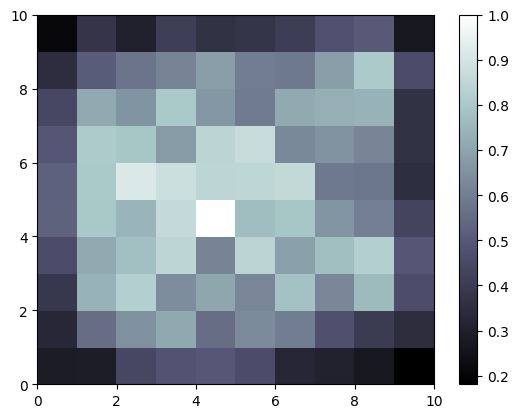

In [13]:
from pylab import bone, pcolor, colorbar, plot, show
bone()
pcolor(som.distance_map().T)
colorbar()

In [14]:
y = target

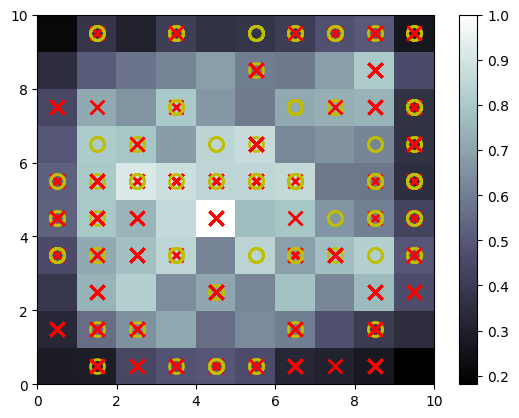

In [38]:
bone()
pcolor(som.distance_map().T)
colorbar()
markers = ['x', 'o'] # x for rejected and o for accepted
colors = ['r', 'y'] # r for red y for yellow
for i, x in enumerate(inputs_scaled):
    w = som.winner(x)
    plot(w[0] + 0.5,
         w[1] + 0.5,
         markers[y[i]],
         markeredgecolor = colors[y[i]],
         markerfacecolor = 'None',
         markersize = 10,
         markeredgewidth = 2)
show()

## Finding the frauds

In [40]:
import numpy as np

fraud_1 = np.array(mappings[(4,4)]).reshape(-1, inputs_scaled.shape[1])
fraud_2 = np.array(mappings[(8,8)]).reshape(-1, inputs_scaled.shape[1])

frauds = np.concatenate((fraud_1, fraud_2), axis=0)

frauds = sc.inverse_transform(frauds)


In [41]:
mappings

defaultdict(list,
            {(np.int64(2),
              np.int64(1)): [array([1.        , 0.12526316, 0.40928571, 0.5       , 0.23076923,
                     0.375     , 0.05561404, 0.        , 0.        , 0.        ,
                     1.        , 0.5       , 0.05      , 0.01212   ]), array([1.        , 0.14030075, 0.08928571, 0.5       , 0.        ,
                     0.        , 0.00298246, 0.        , 0.        , 0.        ,
                     1.        , 0.5       , 0.05      , 0.04208   ]), array([1.00000000e+00, 5.26315789e-02, 1.07142857e-01, 5.00000000e-01,
                     2.30769231e-01, 3.75000000e-01, 1.40350877e-03, 0.00000000e+00,
                     0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 5.00000000e-01,
                     8.00000000e-02, 4.00000000e-04]), array([1.        , 0.15533835, 0.32142857, 0.5       , 0.38461538,
                     0.375     , 0.00877193, 0.        , 0.        , 0.        ,
                     1.        , 0.5       ,

In [42]:
frauds

array([[0.0000e+00, 5.6830e+01, 4.2500e+00, 1.0000e+00, 1.0000e+00,
        1.0000e+00, 5.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        1.0000e+00, 2.0000e+00, 0.0000e+00, 5.0000e+00],
       [0.0000e+00, 5.3330e+01, 1.6500e-01, 2.0000e+00, 1.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        1.0000e+00, 1.0000e+00, 6.2000e+01, 2.8000e+01],
       [0.0000e+00, 2.6580e+01, 2.5400e+00, 1.0000e+00, 1.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        1.0000e+00, 2.0000e+00, 1.8000e+02, 6.1000e+01],
       [0.0000e+00, 6.9500e+01, 6.0000e+00, 2.0000e+00, 1.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00],
       [0.0000e+00, 3.0250e+01, 5.5000e+00, 2.0000e+00, 4.0000e+00,
        4.0000e+00, 5.5000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        1.0000e+00, 1.0000e+00, 1.0000e+02, 1.0000e+00],
       [0.0000e+00, 2.2500e+01, 4.1

In [43]:
frauds_df = pd.DataFrame(frauds, columns=inputs.columns)

frauds_df

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14
0,0.0,56.83,4.250,1.0,1.0,1.0,5.000,0.0,0.0,0.0,1.0,2.0,0.0,5.0
1,0.0,53.33,0.165,2.0,1.0,1.0,0.000,0.0,0.0,0.0,1.0,1.0,62.0,28.0
2,0.0,26.58,2.540,1.0,1.0,1.0,0.000,0.0,0.0,0.0,1.0,2.0,180.0,61.0
3,0.0,69.50,6.000,2.0,1.0,1.0,0.000,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,0.0,30.25,5.500,2.0,4.0,4.0,5.500,0.0,0.0,0.0,1.0,1.0,100.0,1.0
5,0.0,22.50,0.415,2.0,3.0,4.0,0.335,0.0,0.0,0.0,1.0,1.0,144.0,1.0
6,1.0,29.42,1.250,2.0,9.0,4.0,1.750,0.0,0.0,0.0,0.0,2.0,200.0,1.0
7,1.0,36.50,4.250,2.0,11.0,4.0,3.500,0.0,0.0,0.0,0.0,2.0,454.0,51.0
8,1.0,29.83,3.500,2.0,8.0,4.0,0.165,0.0,0.0,0.0,0.0,2.0,216.0,1.0
9,1.0,42.75,4.085,2.0,6.0,4.0,0.040,0.0,0.0,0.0,0.0,2.0,108.0,101.0


# Advanced hyperparameter optimization

In [17]:
import optuna
from sklearn.metrics import silhouette_score

def objective(trial):

    x = trial.suggest_int("x", 10, 20)  # Grid size x
    y = trial.suggest_int("y", 10, 20)  # Grid size y
    sigma = trial.suggest_float("sigma", 0.1, 2.0, log=True)  # Spread of the neighborhood
    learning_rate = trial.suggest_float("learning_rate", 0.01, 1.0, log=True)  # Learning rate
    num_iteration = trial.suggest_int("num_iteration", 50, 500)  # Training iterations

    # Initialize SOM
    som = MiniSom(x=x, y=y, input_len=inputs_scaled.shape[1], sigma=sigma, learning_rate=learning_rate)
    som.random_weights_init(inputs_scaled)
    som.train_random(data=inputs_scaled, num_iteration=num_iteration)
    
    # Assign each input to the closest SOM neuron
    labels = np.array([som.winner(x) for x in inputs_scaled])
    print(labels)
    # Flatten the neuron indices for silhouette_score
    flattened_labels = [i[0] * y + i[1] for i in labels]
    
    # Evaluate clustering using silhouette score (higher is better)
    try:
        score = silhouette_score(inputs_scaled, flattened_labels)
    except ValueError:
        score = -1  # Assign a negative score if clustering fails
    
    return score

# Run the optimization
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=1)

# Display the best parameters
print("Best parameters:", study.best_params)
print("Best silhouette score:", study.best_value)


[I 2025-04-02 18:38:17,767] A new study created in memory with name: no-name-5d6f9566-de8c-4c8c-a60b-95bda49cc525
[I 2025-04-02 18:38:17,801] Trial 0 finished with value: 0.15495569676402193 and parameters: {'x': 10, 'y': 10, 'sigma': 0.17240251369138612, 'learning_rate': 0.25871545178080774, 'num_iteration': 326}. Best is trial 0 with value: 0.15495569676402193.


[[2 1]
 [3 2]
 [8 9]
 ...
 [1 7]
 [7 5]
 [5 2]]
Best parameters: {'x': 10, 'y': 10, 'sigma': 0.17240251369138612, 'learning_rate': 0.25871545178080774, 'num_iteration': 326}
Best silhouette score: 0.15495569676402193


In [46]:
best_params = study.best_params
best_params

{'x': 16,
 'y': 12,
 'sigma': 0.7709627856753185,
 'learning_rate': 0.8143164009076099,
 'num_iteration': 399}

In [48]:
# Initialize SOM with the best parameters
som_opt = MiniSom(x=best_params['x'], y=best_params['y'], input_len=14,
              sigma=best_params['sigma'], learning_rate=best_params['learning_rate'])

som_opt.random_weights_init(inputs_scaled)

som_opt.train_random(data=inputs_scaled, num_iteration=best_params['num_iteration'])


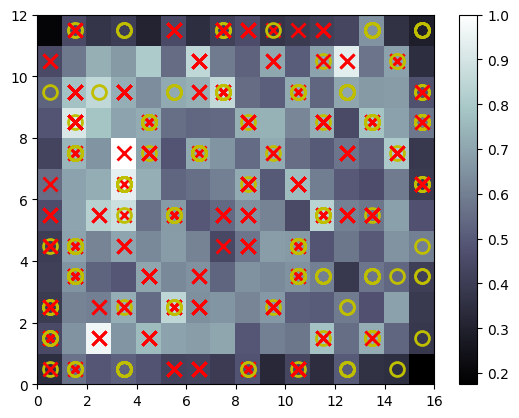

In [49]:
# Original Plot Code
bone()
pcolor(som_opt.distance_map().T)  # Display the distance map
colorbar()
markers = ['x', 'o']  # x for rejected and o for accepted
colors = ['r', 'y']  # r for red and y for yellow

for i, x in enumerate(inputs_scaled):
    w = som_opt.winner(x)
    plot(w[0] + 0.5,
         w[1] + 0.5,
         markers[y[i]],
         markeredgecolor=colors[y[i]],
         markerfacecolor='None',
         markersize=10,
         markeredgewidth=2)

show()

In [50]:
distance_map = som_opt.distance_map()

threshold = 0.9

white_nodes = [(i, j) for i in range(distance_map.shape[0]) for j in range(distance_map.shape[1]) if distance_map[i, j] >= threshold]

print("Positions of Nodes (Distance >= 0.9):")
for node in white_nodes:
    print(f"Node {node} - Distance: {distance_map[node[0], node[1]]:.2f}")


Positions of Nodes (Distance >= 0.9):
Node (1, 8) - Distance: 0.91
Node (2, 1) - Distance: 0.96
Node (3, 6) - Distance: 0.94
Node (3, 7) - Distance: 1.00
Node (12, 10) - Distance: 0.93


In [100]:
mappings = som_opt.win_map(inputs_scaled)

frauds = []

for node in white_nodes:
    if node in mappings:
        fraud_data = mappings[node]
        frauds.append(fraud_data)

frauds = np.concatenate(frauds, axis=0)

frauds = sc.inverse_transform(frauds)

frauds

array([[0.0000e+00, 3.0420e+01, 1.3750e+00, 2.0000e+00, 9.0000e+00,
        8.0000e+00, 4.0000e-02, 0.0000e+00, 1.0000e+00, 3.0000e+00,
        0.0000e+00, 2.0000e+00, 0.0000e+00, 3.4000e+01],
       [0.0000e+00, 3.5170e+01, 3.7500e+00, 2.0000e+00, 1.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 6.0000e+00,
        0.0000e+00, 2.0000e+00, 0.0000e+00, 2.0100e+02],
       [0.0000e+00, 1.6500e+01, 1.2500e+00, 2.0000e+00, 1.1000e+01,
        4.0000e+00, 2.5000e-01, 0.0000e+00, 1.0000e+00, 1.0000e+00,
        0.0000e+00, 2.0000e+00, 1.0800e+02, 9.9000e+01],
       [0.0000e+00, 2.3000e+01, 1.8350e+00, 2.0000e+00, 5.0000e+00,
        3.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00,
        0.0000e+00, 2.0000e+00, 2.0000e+02, 5.4000e+01],
       [0.0000e+00, 1.6080e+01, 3.3500e-01, 2.0000e+00, 1.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00,
        0.0000e+00, 2.0000e+00, 1.6000e+02, 1.2700e+02],
       [0.0000e+00, 4.0330e+01, 8.1

In [118]:
frauds_df = pd.DataFrame(frauds, columns=inputs.columns)

frauds_df

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14
0,0.0,30.42,1.375,2.0,9.0,8.0,0.040,0.0,1.0,3.0,0.0,2.0,0.0,34.0
1,0.0,35.17,3.750,2.0,1.0,1.0,0.000,0.0,1.0,6.0,0.0,2.0,0.0,201.0
2,0.0,16.50,1.250,2.0,11.0,4.0,0.250,0.0,1.0,1.0,0.0,2.0,108.0,99.0
3,0.0,23.00,1.835,2.0,5.0,3.0,0.000,0.0,1.0,1.0,0.0,2.0,200.0,54.0
4,0.0,16.08,0.335,2.0,1.0,1.0,0.000,0.0,1.0,1.0,0.0,2.0,160.0,127.0
5,0.0,40.33,8.125,1.0,4.0,4.0,0.165,0.0,1.0,2.0,0.0,2.0,184.0,19.0
6,0.0,20.08,0.125,2.0,11.0,4.0,1.000,0.0,1.0,1.0,0.0,2.0,240.0,769.0
7,0.0,36.58,0.290,2.0,1.0,1.0,0.000,0.0,1.0,10.0,0.0,2.0,200.0,19.0
8,0.0,27.17,1.250,2.0,1.0,1.0,0.000,0.0,1.0,1.0,0.0,2.0,92.0,301.0
9,0.0,57.58,2.000,2.0,1.0,1.0,6.500,0.0,1.0,1.0,0.0,2.0,0.0,11.0


In [116]:
df

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class,is_fraud
0,15776156,1,22.08,11.460,2,4,4,1.585,0,0,0,1,2,100,1213,0,0
1,15739548,0,22.67,7.000,2,8,4,0.165,0,0,0,0,2,160,1,0,0
2,15662854,0,29.58,1.750,1,4,4,1.250,0,0,0,1,2,280,1,0,0
3,15687688,0,21.67,11.500,1,5,3,0.000,1,1,11,1,2,0,1,1,0
4,15715750,1,20.17,8.170,2,6,4,1.960,1,1,14,0,2,60,159,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,15808223,1,31.57,10.500,2,14,4,6.500,1,0,0,0,2,0,1,1,0
686,15769980,1,20.67,0.415,2,8,4,0.125,0,0,0,0,2,0,45,0,0
687,15675450,0,18.83,9.540,2,6,4,0.085,1,0,0,0,2,100,1,1,0
688,15776494,0,27.42,14.500,2,14,8,3.085,1,1,1,0,2,120,12,1,0


# From Unsupervised to Supervised

In [119]:
common_cols = list(set(df.columns) & set(frauds_df.columns)) 

common_cols

['A6',
 'A13',
 'A5',
 'A4',
 'A12',
 'A8',
 'A2',
 'A3',
 'A11',
 'A1',
 'A10',
 'A14',
 'A9',
 'A7']

In [124]:
df1 = df.merge(frauds_df[common_cols].assign(is_fraud=1), how="left", on=common_cols)

df1

/var/folders/br/yvkmbr3121n8fd9q6wdmyqfm0000gp/T/ipykernel_77150/2530197955.py:1: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  df1 = df.merge(frauds_df[common_cols].assign(is_fraud=1), how="left", on=common_cols)


,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class,is_fraud
0,15776156,1,22.08,11.460,2,4,4,1.585,0,0,0,1,2,100,1213,0,NaN
1,15739548,0,22.67,7.000,2,8,4,0.165,0,0,0,0,2,160,1,0,NaN
2,15662854,0,29.58,1.750,1,4,4,1.250,0,0,0,1,2,280,1,0,NaN
3,15687688,0,21.67,11.500,1,5,3,0.000,1,1,11,1,2,0,1,1,NaN
4,15715750,1,20.17,8.170,2,6,4,1.960,1,1,14,0,2,60,159,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,15808223,1,31.57,10.500,2,14,4,6.500,1,0,0,0,2,0,1,1,NaN
686,15769980,1,20.67,0.415,2,8,4,0.125,0,0,0,0,2,0,45,0,NaN
687,15675450,0,18.83,9.540,2,6,4,0.085,1,0,0,0,2,100,1,1,NaN
688,15776494,0,27.42,14.500,2,14,8,3.085,1,1,1,0,2,120,12,1,NaN


In [125]:
df1["is_fraud"] = np.where(df1["is_fraud"].isna(),0,1)

df1

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class,is_fraud
0,15776156,1,22.08,11.460,2,4,4,1.585,0,0,0,1,2,100,1213,0,0
1,15739548,0,22.67,7.000,2,8,4,0.165,0,0,0,0,2,160,1,0,0
2,15662854,0,29.58,1.750,1,4,4,1.250,0,0,0,1,2,280,1,0,0
3,15687688,0,21.67,11.500,1,5,3,0.000,1,1,11,1,2,0,1,1,0
4,15715750,1,20.17,8.170,2,6,4,1.960,1,1,14,0,2,60,159,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,15808223,1,31.57,10.500,2,14,4,6.500,1,0,0,0,2,0,1,1,0
686,15769980,1,20.67,0.415,2,8,4,0.125,0,0,0,0,2,0,45,0,0
687,15675450,0,18.83,9.540,2,6,4,0.085,1,0,0,0,2,100,1,1,0
688,15776494,0,27.42,14.500,2,14,8,3.085,1,1,1,0,2,120,12,1,0


In [127]:
df1.drop(['CustomerID'], axis=1, inplace=True)

In [128]:
targets = df1['is_fraud']

inputs = df1.drop(['is_fraud'],axis=1)

In [129]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(inputs)

scaled = scaler.transform(inputs)

inputs_scaled = pd.DataFrame(scaled, columns=inputs.columns)

inputs_scaled

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,0.688737,-0.801052,1.347111,0.542950,-0.916282,-0.347965,-0.190906,-1.047504,-0.864196,-0.493887,1.087908,0.237828,-0.488358,0.037380,-0.895303
1,-1.451933,-0.751240,0.450548,0.542950,0.170499,-0.347965,-0.615536,-1.047504,-0.864196,-0.493887,-0.919195,0.237828,-0.139591,-0.195413,-0.895303
2,-1.451933,-0.167856,-0.604823,-1.783978,-0.916282,-0.347965,-0.291083,-1.047504,-0.864196,-0.493887,1.087908,0.237828,0.557943,-0.195413,-0.895303
3,-1.451933,-0.835667,1.355152,-1.783978,-0.644587,-0.850257,-0.664877,0.954650,1.157144,1.769760,1.087908,0.237828,-1.069637,-0.195413,1.116941
4,0.688737,-0.962306,0.685745,0.542950,-0.372892,-0.347965,-0.078768,0.954650,1.157144,2.387119,-0.919195,0.237828,-0.720870,-0.165066,1.116941
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,0.688737,0.000152,1.154129,0.542950,1.800670,-0.347965,1.278852,0.954650,-0.864196,-0.493887,-0.919195,0.237828,-1.069637,-0.195413,1.116941
686,0.688737,-0.920093,-0.873189,0.542950,0.170499,-0.347965,-0.627497,-1.047504,-0.864196,-0.493887,-0.919195,0.237828,-1.069637,-0.186962,-0.895303
687,-1.451933,-1.075437,0.961146,0.542950,-0.372892,-0.347965,-0.639459,0.954650,-0.864196,-0.493887,-0.919195,0.237828,-0.488358,-0.195413,1.116941
688,-1.451933,-0.350217,1.958221,0.542950,1.800670,1.661205,0.257647,0.954650,1.157144,-0.288101,-0.919195,0.237828,-0.372103,-0.193301,1.116941


In [130]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(inputs_scaled, targets, test_size=0.2, random_state=42)

In [134]:
import optuna
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta, Nadam
from sklearn.metrics import roc_auc_score

In [152]:
def create_model(trial):
    model = Sequential()
    model.add(Dense(units=trial.suggest_int('units_layer1', 6, 32), activation='relu'))
    model.add(Dense(units=trial.suggest_int('units_layer2', 6, 32), activation='relu'))
    model.add(Dense(units=1, activation='sigmoid'))

    optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'sgd', 'rmsprop', 'adagrad'])
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)
    
    if optimizer_name == 'adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer_name == 'sgd':
        optimizer = SGD(learning_rate=learning_rate)
    elif optimizer_name == 'rmsprop':
        optimizer = RMSprop(learning_rate=learning_rate)
    elif optimizer_name == 'adagrad':
        optimizer = Adagrad(learning_rate=learning_rate)
    
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['AUC'])
    
    return model

In [154]:
def optimal(trial):
    
    epochs = trial.suggest_int('epochs', 10, 50)
    batch_size = trial.suggest_int('batch_size', 16, 64)
    
    model = create_model(trial)
    
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size)
    
    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, y_pred)
    
    return auc

study = optuna.create_study(direction='maximize')
study.optimize(optimal, n_trials=10)

print(f"Best trial: {study.best_trial.value}")
print(f"Best hyperparameters: {study.best_trial.params}")

[I 2025-03-31 15:31:04,950] A new study created in memory with name: no-name-f9ea79df-cb0b-40b5-82c8-3fe81efca3b4


Epoch 1/20


/var/folders/br/yvkmbr3121n8fd9q6wdmyqfm0000gp/T/ipykernel_77150/1155345330.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 952us/step - AUC: 0.3442 - loss: 0.3910
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.1853 - loss: 0.3448    
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 916us/step - AUC: 0.4358 - loss: 0.2494  
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 993us/step - AUC: 0.4307 - loss: 0.2256
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 788us/step - AUC: 0.3988 - loss: 0.2459
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 877us/step - AUC: 0.4060 - loss: 0.1849  
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 885us/step - AUC: 0.4271 - loss: 0.2084
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 844us/step - AUC: 0.5111 - loss: 0.1899
Epoch 9/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 872us/step - AUC: 0.5417 - loss: 0.1907
Epoch 10/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - AUC: 0.5284 - loss: 0.1949
Epoch 11/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 848us/step - AUC: 0.6698 - loss: 0.1604
Epoch 12/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 894us/step - AUC: 0.6188 - loss: 0.1462
Epoch 13/20
22/22 ━━━━━━━━━━━━

[I 2025-03-31 15:31:05,870] Trial 0 finished with value: 0.8469135802469135 and parameters: {'epochs': 20, 'batch_size': 26, 'units_layer1': 7, 'units_layer2': 27, 'optimizer': 'rmsprop', 'learning_rate': 0.0007795473336889514}. Best is trial 0 with value: 0.8469135802469135.


...

Epoch 1/24


/var/folders/br/yvkmbr3121n8fd9q6wdmyqfm0000gp/T/ipykernel_77150/1155345330.py:8: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-2)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.5003 - loss: 0.8817      
Epoch 2/24
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.5520 - loss: 0.8267
Epoch 3/24
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.7002 - loss: 0.7921
Epoch 4/24
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.5096 - loss: 0.7890    
Epoch 5/24
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.5246 - loss: 0.7705
Epoch 6/24
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.5873 - loss: 0.7484
Epoch 7/24
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.6530 - loss: 0.7252
Epoch 8/24
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.6158 - loss: 0.6988
Epoch 9/24
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 955us/step - AUC: 0.6164 - loss: 0.6777
Epoch 10/24
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.5260 - loss: 0.6757
Epoch 11/24
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.6773 - loss: 0.6326
Epoch 12/24
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.6892 - loss: 0.6257
Epoch 13/24
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/st

[I 2025-03-31 15:31:14,164] Trial 9 finished with value: 0.6197530864197531 and parameters: {'epochs': 24, 'batch_size': 44, 'units_layer1': 10, 'units_layer2': 16, 'optimizer': 'sgd', 'learning_rate': 0.0016406943658539965}. Best is trial 3 with value: 0.9481481481481482.


Best trial: 0.9481481481481482
Best hyperparameters: {'epochs': 29, 'batch_size': 30, 'units_layer1': 19, 'units_layer2': 19, 'optimizer': 'adam', 'learning_rate': 0.0010889774151930326}


In [155]:
best_params = study.best_trial.params

best_params

{'epochs': 29,
 'batch_size': 30,
 'units_layer1': 19,
 'units_layer2': 19,
 'optimizer': 'adam',
 'learning_rate': 0.0010889774151930326}

In [156]:
best_model = Sequential()
best_model.add(Dense(units=best_params['units_layer1'], activation='relu'))
best_model.add(Dense(units=best_params['units_layer2'], activation='relu'))
best_model.add(Dense(1, activation='sigmoid'))

In [157]:
if best_params['optimizer'] == 'adam':
    best_optimizer = Adam(learning_rate=best_params['learning_rate'])
elif best_params['optimizer'] == 'sgd':
    best_optimizer = SGD(learning_rate=best_params['learning_rate'])
elif best_params['optimizer'] == 'rmsprop':
    best_optimizer = RMSprop(learning_rate=best_params['learning_rate'])
elif best_params['optimizer'] == 'adagrad':
    best_optimizer = Adagrad(learning_rate=best_params['learning_rate'])


In [158]:
best_model.compile(optimizer=best_optimizer, loss='binary_crossentropy', metrics=['AUC'])

In [159]:
def evaluate(model, X_train, y_train, X_test, y_test):
    
    model.fit(X_train, y_train, epochs=best_params['epochs'], batch_size=best_params['batch_size'])
    
    '''Predictions and probabilities for the training set'''
    
    y_train_prob = model.predict(X_train)

    '''Predictions and probabilities for the test set'''
    
    y_test_prob = model.predict(X_test)

    '''Calculate metrics for the training set''' 
    
    roc_train_prob = roc_auc_score(y_train, y_train_prob)
    gini_train_prob = roc_train_prob * 2 - 1
    

    '''Calculate metrics for the test set'''
    
    roc_test_prob = roc_auc_score(y_test, y_test_prob)
    gini_test_prob = roc_test_prob * 2 - 1
    

    results = pd.DataFrame({
        'Dataset': ['Train', 'Test'],
        'Gini': [gini_train_prob * 100, gini_test_prob * 100],
    
    })

    return results

In [160]:
evaluate(best_model, X_train, y_train, X_test, y_test)

Epoch 1/29
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 969us/step - AUC: 0.6435 - loss: 0.7169
Epoch 2/29
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.4871 - loss: 0.5051
Epoch 3/29
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.3704 - loss: 0.3570
Epoch 4/29
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.4685 - loss: 0.2711
Epoch 5/29
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.4451 - loss: 0.2097
Epoch 6/29
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 902us/step - AUC: 0.6353 - loss: 0.2051
Epoch 7/29
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 927us/step - AUC: 0.6657 - loss: 0.1986
Epoch 8/29
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.7530 - loss: 0.1459    
Epoch 9/29
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 946us/step - AUC: 0.7090 - loss: 0.1848
Epoch 10/29
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 859us/step - AUC: 0.6950 - loss: 0.1695
Epoch 11/29
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 873us/step - AUC: 0.8048 - loss: 0.1491
Epoch 12/29
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 893us/step - AUC: 0.7962 - loss: 0.1410
Epoch 13/29
19/19 ━━━━━━━━━━━━━

,Dataset,Gini
0,Train,96.986817
1,Test,94.074074


In [162]:
best_model.save("som_ann_model.h5")

# Deployment

In [168]:
model = tf.keras.models.load_model("som_ann_model.h5")

model.summary()

Model: "sequential_42"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_126 (Dense)               │ (None, 19)             │           304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_127 (Dense)               │ (None, 19)             │           380 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 1)              │            20 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 706 (2.76 KB)

 Trainable params: 704 (2.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [169]:
test_df = df.sample(30)

In [170]:
test_df

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
686,15769980,1,20.67,0.415,2,8,4,0.125,0,0,0,0,2,0,45,0
488,15785367,1,51.33,10.000,2,3,5,0.000,1,1,11,0,2,0,1250,1
422,15646521,1,29.83,1.250,1,4,4,0.250,0,0,0,0,2,224,1,0
88,15615832,1,34.17,5.250,2,9,4,0.085,0,0,0,1,2,290,7,1
670,15672357,0,37.75,5.500,2,11,4,0.125,1,0,0,1,2,228,1,1
34,15813718,1,42.83,1.250,2,7,4,13.875,0,1,1,1,2,352,113,0
466,15772941,0,65.17,14.000,2,1,1,0.000,1,1,11,1,2,0,1401,1
164,15649379,1,42.75,3.000,2,3,5,1.000,1,0,0,0,2,0,201,0
580,15649101,1,23.92,0.585,1,13,8,0.125,0,0,0,0,2,240,2,0
136,15788442,1,19.58,0.585,2,1,1,0.000,0,1,3,0,2,350,770,0


In [174]:
scaled_test = scaler.transform(test_df.iloc[:,1:])

test_scaled = pd.DataFrame(scaled_test, columns=test_df.iloc[:,1:].columns)

test_scaled

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,0.688737,-0.920093,-0.873189,0.542950,0.170499,-0.347965,-0.627497,-1.047504,-0.864196,-0.493887,-0.919195,0.237828,-1.069637,-0.186962,-0.895303
1,0.688737,1.668411,1.053617,0.542950,-1.187977,0.154328,-0.664877,0.954650,1.157144,1.769760,-0.919195,0.237828,-1.069637,0.044487,1.116941
2,0.688737,-0.146750,-0.705334,-1.783978,-0.916282,-0.347965,-0.590118,-1.047504,-0.864196,-0.493887,-0.919195,0.237828,0.232427,-0.195413,-0.895303
3,0.688737,0.219660,0.098758,0.542950,0.442194,-0.347965,-0.639459,-1.047504,-0.864196,-0.493887,1.087908,0.237828,0.616071,-0.194261,1.116941
4,-1.451933,0.521905,0.149013,0.542950,0.985584,-0.347965,-0.627497,0.954650,-0.864196,-0.493887,1.087908,0.237828,0.255678,-0.195413,1.116941
5,0.688737,0.950789,-0.705334,0.542950,-0.101197,-0.347965,3.484237,-1.047504,1.157144,-0.288101,1.087908,0.237828,0.976464,-0.173901,-0.895303
6,-1.451933,2.836868,1.857709,0.542950,-1.731368,-1.854842,-0.664877,0.954650,1.157144,1.769760,1.087908,0.237828,-1.069637,0.073490,1.116941
7,0.688737,0.944035,-0.353544,0.542950,-1.187977,0.154328,-0.365841,0.954650,-0.864196,-0.493887,-0.919195,0.237828,-1.069637,-0.156999,-0.895303
8,0.688737,-0.645708,-0.839015,-1.783978,1.528975,1.661205,-0.627497,-1.047504,-0.864196,-0.493887,-0.919195,0.237828,0.325432,-0.195221,-0.895303
9,0.688737,-1.012117,-0.839015,0.542950,-1.731368,-1.854842,-0.664877,-1.047504,1.157144,0.123472,-0.919195,0.237828,0.964839,-0.047708,-0.895303


In [175]:
test_df['prediction'] = model.predict(test_scaled)

test_df

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class,prediction
686,15769980,1,20.67,0.415,2,8,4,0.125,0,0,0,0,2,0,45,0,0.000366
488,15785367,1,51.33,10.000,2,3,5,0.000,1,1,11,0,2,0,1250,1,0.588811
422,15646521,1,29.83,1.250,1,4,4,0.250,0,0,0,0,2,224,1,0,0.005278
88,15615832,1,34.17,5.250,2,9,4,0.085,0,0,0,1,2,290,7,1,0.000772
670,15672357,0,37.75,5.500,2,11,4,0.125,1,0,0,1,2,228,1,1,0.000859
34,15813718,1,42.83,1.250,2,7,4,13.875,0,1,1,1,2,352,113,0,0.013336
466,15772941,0,65.17,14.000,2,1,1,0.000,1,1,11,1,2,0,1401,1,0.035588
164,15649379,1,42.75,3.000,2,3,5,1.000,1,0,0,0,2,0,201,0,0.010713
580,15649101,1,23.92,0.585,1,13,8,0.125,0,0,0,0,2,240,2,0,0.000019
136,15788442,1,19.58,0.585,2,1,1,0.000,0,1,3,0,2,350,770,0,0.152658
